**1. Helper: Decision Region Plot**

This code defines a helper function that visualizes a neural network's decision boundary in 2D. It creates a grid of points, predicts the class for each point using your trained model, and plots the results as shaded background colors alongside your data points. You need to run this block first, as it is reused in Activities 9.1 through 9.8.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_regions(model, X, y, title="Decision Regions", steps=300):
    # Determine the minimum and maximum boundaries for the plot
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # Create a meshgrid grid of points spanning the feature space
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, steps), np.linspace(y_min, y_max, steps))
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Predict the class for each point on the grid (thresholded at 0.5)
    Z = (model.predict(grid, verbose=0) > 0.5).astype(int).ravel()
    Z = Z.reshape(xx.shape)

    # Plot the decision boundaries and data points
    plt.figure(figsize=(5, 4))
    plt.contourf(xx, yy, Z, alpha=0.35)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k')
    plt.title(title)
    plt.tight_layout()
    plt.show()

**2. Activity 9.1 – Perceptron on a Linearly Separable Set**

This block trains a single-neuron classifier (a Perceptron logic unit with a sigmoid activation function) on an easy, linearly separable 2D dataset. It shows how the model calculates a straightforward straight line to split two distinct data groups.

c:\Users\inoja\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


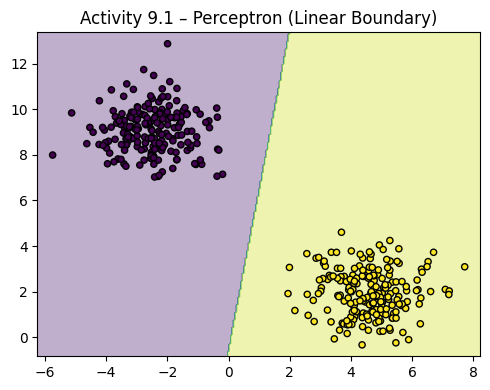

In [2]:
from sklearn.datasets import make_blobs
from tensorflow import keras
from tensorflow.keras import layers

# Generate a synthetic dataset containing two linearly separable blobs
X, y = make_blobs(n_samples=400, centers=2, cluster_std=1.0, random_state=42)

# Build a Sequential model with a single neuron (linear boundary output)
model = keras.Sequential([
    layers.Dense(1, activation='sigmoid', input_shape=(2,))
])

# Compile the model using Stochastic Gradient Descent (SGD)
model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model over 40 training epochs
model.fit(X, y, epochs=40, verbose=0)

# Use the helper function to visualize the straight-line decision boundary
plot_decision_regions(model, X, y, title="Activity 9.1 – Perceptron (Linear Boundary)")

**3. Activity 9.2 – MLP Solves Non-Linear Boundaries**

This activity shifts to a non-linear dataset (make_moons). It builds a Multi-Layer Perceptron (MLP) with two hidden layers using ReLU activation functions to demonstrate how adding hidden layers enables the network to warp and wrap around complex, non-linear boundaries.

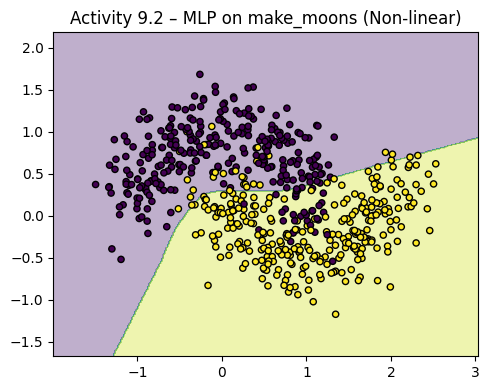

In [3]:
from sklearn.datasets import make_moons

# Generate a non-linear, moon-shaped dataset
X, y = make_moons(n_samples=600, noise=0.25, random_state=42)

# Construct a deeper network with hidden layers to manage non-linearity
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(2,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Final output layer for binary classification
])

# Compile using the Adam optimizer
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the network with a batch size of 64
model.fit(X, y, epochs=50, batch_size=64, verbose=0)

# Plot the resulting non-linear decision boundary
plot_decision_regions(model, X, y, title="Activity 9.2 – MLP on make_moons (Non‑linear)")

**4. Activity 9.3 – Activation Functions in Practice (ReLU vs Tanh)**

This block sets up two identical network configurations but swaps out their internal activation functions—one uses ReLU, and the other uses Tanh. It tracks and prints execution times while letting you compare how choice of activation impacts boundary sharpness and execution speed.

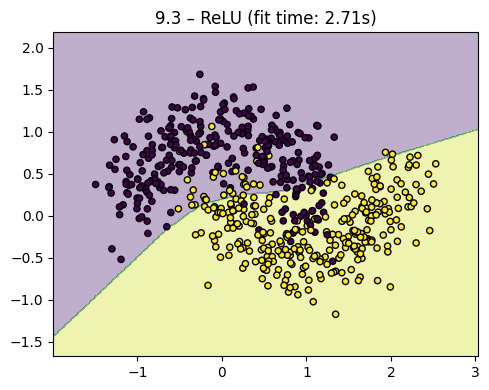

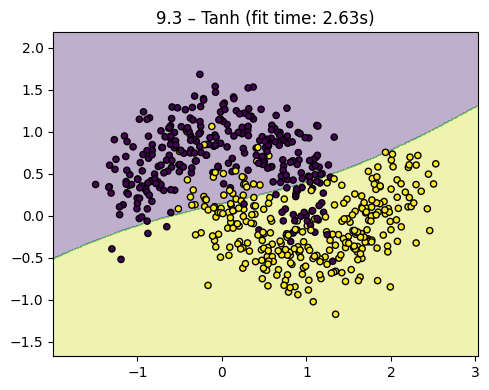

ReLU fit time: 2.71s
Tanh fit time: 2.63s


In [ ]:
import time

# 1. Build and train the model using ReLU activation functions
relu_model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(2,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
relu_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

t0 = time.time()
relu_model.fit(X, y, epochs=40, batch_size=64, verbose=0)
relu_time = time.time() - t0

# Visualize results for the ReLU configuration
plot_decision_regions(relu_model, X, y, title=f"9.3 – ReLU (fit time: {relu_time:.2f}s)")

# 2. Build and train an identical model using Tanh activation functions instead
tanh_model = keras.Sequential([
    layers.Dense(16, activation='tanh', input_shape=(2,)),
    layers.Dense(16, activation='tanh'),
    layers.Dense(1, activation='sigmoid')
])
tanh_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

t0 = time.time()
tanh_model.fit(X, y, epochs=40, batch_size=64, verbose=0)
tanh_time = time.time() - t0

# Visualize results for the Tanh configuration
plot_decision_regions(tanh_model, X, y, title=f"9.3 – Tanh (fit time: {tanh_time:.2f}s)")

# Output a side-by-side time summary
print(f"ReLU fit time: {relu_time:.2f}s")
print(f"Tanh fit time: {tanh_time:.2f}s")

**5. Activity 9.4 – Batch Size and Convergence**

This script loops through three distinct batch sizes (16, 128, and 512) to observe training dynamics. It demonstrates how smaller batches provide more frequent updates but take longer per epoch, whereas overly large batches finish faster but can achieve lower overall accuracy.

In [ ]:
import time

sizes = [16, 128, 512]

# Loop through each distinct batch size to evaluate its performance
for b in sizes:
    m = keras.Sequential([
        layers.Dense(16, activation='relu', input_shape=(2,)),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Measure execution duration for the current batch size configuration
    t0 = time.time()
    m.fit(X, y, epochs=25, batch_size=b, verbose=0)
    dt = time.time() - t0

    # Evaluate the performance metrics against the dataset
    acc = m.evaluate(X, y, verbose=0)[1]
    print(f"Batch {b}: trained in {dt:.2f}s; acc={acc:.3f}")

Batch 16: trained in 2.66s; acc=0.897
Batch 128: trained in 1.77s; acc=0.865
Batch 512: trained in 1.77s; acc=0.768


**6. Activity 9.5 – Weight Initialization (He vs Glorot)**

This code compares glorot_uniform (Xavier) against he_normal initialization strategies. It runs both frameworks on a network utilizing ReLU activations to highlight why specific initialization pairings are crucial for fast optimization stability.

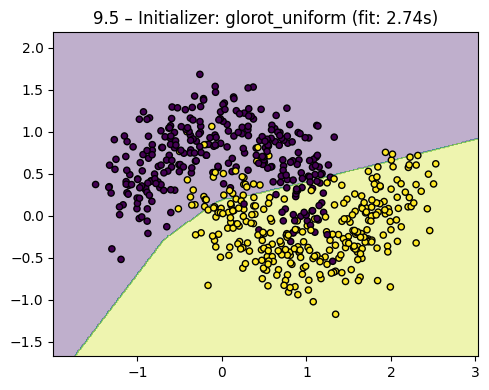

Initializer glorot_uniform: fit time = 2.74s; acc=0.877


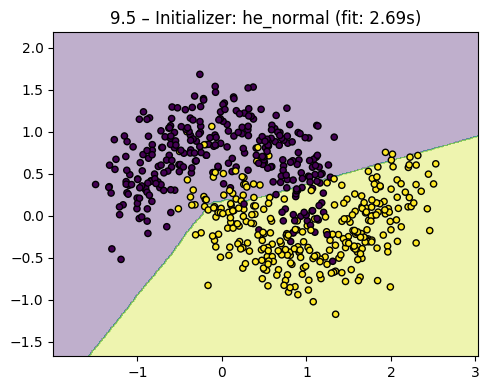

Initializer he_normal: fit time = 2.69s; acc=0.878


In [ ]:
import time

# Compare Glorot (default initialization) vs He normal initialization
for init in ["glorot_uniform", "he_normal"]:
    m = keras.Sequential([
        layers.Dense(16, activation='relu', kernel_initializer=init, input_shape=(2,)),
        layers.Dense(16, activation='relu', kernel_initializer=init),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    t0 = time.time()
    m.fit(X, y, epochs=40, batch_size=64, verbose=0)
    dt = time.time() - t0

    # Plot boundaries and metrics to verify the impact of weight initialization
    plot_decision_regions(m, X, y, title=f"9.5 – Initializer: {init} (fit: {dt:.2f}s)")
    acc = m.evaluate(X, y, verbose=0)[1]
    print(f"Initializer {init}: fit time = {dt:.2f}s; acc={acc:.3f}")

**7. Activity 9.6 – Regularisation with Dropout**

This segment introduces a Dropout layer (omitting 40% of the nodes randomly per step) into a dense model architecture. It evaluates against a standalone validation subset split to illustrate how regularizers smooth boundaries and protect networks from overfitting noise.

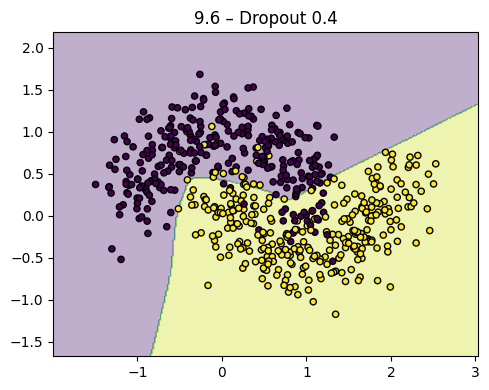

In [ ]:
# Create a broader network but mitigate risk with a Dropout layer
m = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(2,)),
    layers.Dropout(0.4), # Randomly sets 40% of input units to 0 at each step during training
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train with 20% validation split tracking
m.fit(X, y, epochs=80, batch_size=64, verbose=0, validation_split=0.2)

# Verify regularized boundary outcomes
plot_decision_regions(m, X, y, title="9.6 – Dropout 0.4")